# Sales Forecasting
### Fresh Analytics - Predicting Item Demand Across Restaurants (2019-2021)

Author : Ajaykanna E
---

**Context:**
In competitive markets, businesses that can accurately forecast demand gain a significant advantage in planning production, inventory, and staffing.
Fresh Analytics wants to understand and predict the demand for various items across its restaurant network.

This notebook walks through the full data science workflow — from raw data exploration to machine learning and deep learning models — to forecast daily sales.

---

**Notebook Structure**

| Section | Topic |
|---------|-------|
| Section 1 | Preliminary Analysis |
| Section 2 | Exploratory Data Analysis |
| Section 3 | Forecasting using Machine Learning Algorithms |
| Section 4 | Forecasting using Deep Learning Algorithms |

---

**Datasets**

| File | Description |
|------|-------------|
| `sales.csv` | date, item_id, item_count, price |
| `items.csv` | id, store_id, name, kcal, cost |
| `resturants.csv` | id, name |


---
## Section 1: Preliminary Analysis


### 1a. Import the Datasets into the Python Environment

Every data science project starts with loading the right tools.

**Why these libraries?**
- `pandas` — the backbone of data manipulation in Python. It lets us load CSVs, filter rows, group data, and reshape tables with just a few lines.
- `numpy` — fast numerical operations on arrays. Needed for sequence creation and math in the LSTM section.
- `matplotlib` and `seaborn` — visualization libraries. Good charts help us spot patterns that raw numbers hide.
- `sklearn` — provides the Linear Regression and Random Forest models plus the MinMaxScaler for data normalization.
- `xgboost` — a powerful gradient boosting library that often wins on tabular/time-series data.
- `tensorflow/keras` — Google's deep learning framework. We use it to build the LSTM model.


In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Core libraries imported.")

Core libraries imported.


In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

print("Machine learning libraries imported.")

Machine learning libraries imported.


In [3]:
# Set a consistent style for all plots in this notebook
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4']

print("Plot style set.")

Plot style set.


In [4]:
# Load all three datasets
sales       = pd.read_csv('sales.csv')
items       = pd.read_csv('items.csv')
restaurants = pd.read_csv('resturants.csv')

print(f"sales.csv       : {sales.shape[0]:,} rows x {sales.shape[1]} columns")
print(f"items.csv       : {items.shape[0]:,} rows x {items.shape[1]} columns")
print(f"resturants.csv  : {restaurants.shape[0]:,} rows x {restaurants.shape[1]} columns")

sales.csv       : 109,600 rows x 4 columns
items.csv       : 100 rows x 5 columns
resturants.csv  : 6 rows x 2 columns


### 1b. Examine the Dataset's Shape and Structure, and Look for Outliers

**Why do we examine structure first?**
Before writing any modeling code, we need to know:
- What columns exist and what type each column is
- Whether any values are missing (which would break our models)
- The scale and range of numerical values
- Whether there are outliers that might distort our analysis

Skipping this step is one of the most common mistakes in data science projects. Models trained on dirty data produce unreliable results no matter how sophisticated they are.


In [5]:
# Preview sales dataset
print("--- sales.csv ---")
sales.head()

--- sales.csv ---


,date,item_id,item_count,price
0,01-01-2019,3,2,58.44
1,01-01-2019,4,22,581.24
2,01-01-2019,12,7,34.09
3,01-01-2019,13,12,50.16
4,01-01-2019,16,136,436.56


In [6]:
# Preview items dataset
print("--- items.csv ---")
items.head()

--- items.csv ---


,id,store_id,name,kcal,cost
0,1,4,Chocolate Cake,554,6.71
1,2,4,Breaded Fish with Vegetables Meal,772,15.09
2,3,1,Sweet Fruity Cake,931,29.22
3,4,1,Amazing Steak Dinner with Rolls,763,26.42
4,5,5,Milk Cake,583,6.07


In [7]:
# Preview restaurants dataset
print("--- resturants.csv ---")
restaurants.head()

--- resturants.csv ---


,id,name
0,1,Bob's Diner
1,2,Beachfront Bar
2,3,Sweet Shack
3,4,Fou Cher
4,5,Corner Cafe


In [10]:
# Data types and non-null counts for sales
print("Sales dataset info:")
print(sales.dtypes)
print(f"Shape: {sales.shape}")

Sales dataset info:
date           object
item_id         int64
item_count      int64
price         float64
dtype: object
Shape: (109600, 4)


In [11]:
# Descriptive statistics for sales
print("Sales descriptive statistics:")
sales.describe().round(2)

Sales descriptive statistics:


,item_id,item_count,price
count,109600.00,109600.00,109600.00
mean,50.50,6.34,58.43
std,28.87,30.00,214.81
min,1.00,0.00,0.00
25%,25.75,0.00,0.00
50%,50.50,0.00,0.00
75%,75.25,0.00,0.00
max,100.00,570.00,2224.80


In [13]:
# Check for missing values in all three datasets
print("Missing values in sales.csv:")
print(sales.isnull().sum())

print("Missing values in items.csv:")
print(items.isnull().sum())

print("Missing values in resturants.csv:")
print(restaurants.isnull().sum())

Missing values in sales.csv:
date          0
item_id       0
item_count    0
price         0
dtype: int64
Missing values in items.csv:
id          0
store_id    0
name        0
kcal        0
cost        0
dtype: int64
Missing values in resturants.csv:
id      0
name    0
dtype: int64


**Observation:**
- No missing values found in any dataset — the data is complete and ready for analysis.
- The `date` column is currently stored as a string (`object` type). We need to convert it to `datetime` so Python can understand it as a date and extract features like day of week, month, year, etc.
- The `price` column represents the total revenue for that item on that day, not the unit price.


**Outlier Detection using the IQR Method**

**Why detect outliers?**
Outliers are data points that are far from the rest of the distribution. They can distort the mean, inflate error metrics, and mislead visualizations like boxplots.

The **IQR (Interquartile Range) method** is a robust way to detect outliers:
- Q1 = 25th percentile, Q3 = 75th percentile
- IQR = Q3 - Q1
- Lower fence = Q1 - 1.5 * IQR
- Upper fence = Q3 + 1.5 * IQR
- Any value outside these fences is flagged as a potential outlier

**Why do we filter zero rows first?**
The sales dataset records every item for every day, even on days when that item was not sold at all.
This means roughly 75% of rows have `item_count = 0`.
If we run IQR on all rows, the result is Q1 = Q3 = 0, so IQR = 0, and every non-zero value gets flagged as an outlier.
That tells us nothing useful. Filtering to non-zero rows first gives us a meaningful distribution to analyze.


In [14]:
# Check proportion of zero-sales rows
total    = len(sales)
nonzero  = len(sales[sales['item_count'] > 0])
zero     = total - nonzero

print(f"Total rows      : {total:,}")
print(f"Non-zero rows   : {nonzero:,}")
print(f"Zero-sale rows  : {zero:,} ({zero/total*100:.1f}%)")

Total rows      : 109,600
Non-zero rows   : 23,484
Zero-sale rows  : 86,116 (78.6%)


In [15]:
# Filter to non-zero rows for outlier analysis
sales_nz = sales[sales['item_count'] > 0].copy()
print(f"Using {len(sales_nz):,} non-zero rows for outlier analysis.")

Using 23,484 non-zero rows for outlier analysis.


In [16]:
# IQR calculation for item_count
Q1  = sales_nz['item_count'].quantile(0.25)
Q3  = sales_nz['item_count'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR

n_outliers = (sales_nz['item_count'] > upper_fence).sum()

print("IQR Outlier Analysis - item_count (non-zero rows):")
print(f"  Q1          : {Q1:.2f}")
print(f"  Q3          : {Q3:.2f}")
print(f"  IQR         : {IQR:.2f}")
print(f"  Upper fence : {upper_fence:.2f}")
print(f"  Outliers    : {n_outliers}")

IQR Outlier Analysis - item_count (non-zero rows):
  Q1          : 1.00
  Q3          : 29.00
  IQR         : 28.00
  Upper fence : 71.00
  Outliers    : 2595


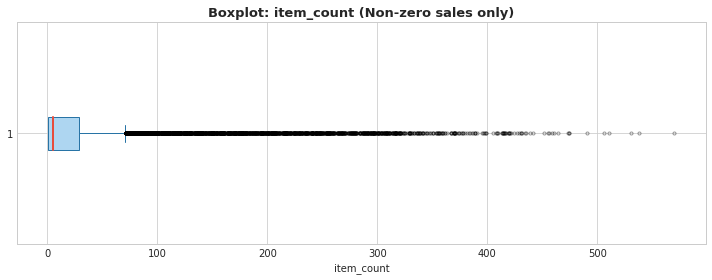

In [17]:
# Boxplot for item_count (non-zero only)
plt.figure(figsize=(10, 4))
plt.boxplot(sales_nz['item_count'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='#AED6F1', color='#2874A6'),
            medianprops=dict(color='#E74C3C', linewidth=2),
            whiskerprops=dict(color='#2874A6'),
            capprops=dict(color='#2874A6'),
            flierprops=dict(marker='o', markersize=3, alpha=0.4, color='#E74C3C'))
plt.title('Boxplot: item_count (Non-zero sales only)', fontsize=13, fontweight='bold')
plt.xlabel('item_count')
plt.tight_layout()
plt.show()

**Observation:**
- The box (Q1 to Q3) is narrow, meaning most items sell in small consistent quantities on any given day.
- The dots to the right of the whisker are items with unusually high sales counts on certain days.
- These are genuine high-demand items — think a popular drink on a busy Friday. They are not data errors, so we keep them in the dataset.
- Removing these would actually make our model worse by stripping out the peaks we want to predict.


In [18]:
# IQR calculation for price
Q1_p  = sales_nz['price'].quantile(0.25)
Q3_p  = sales_nz['price'].quantile(0.75)
IQR_p = Q3_p - Q1_p
upper_fence_p = Q3_p + 1.5 * IQR_p

n_outliers_p = (sales_nz['price'] > upper_fence_p).sum()

print("IQR Outlier Analysis - price (non-zero rows):")
print(f"  Q1          : {Q1_p:.2f}")
print(f"  Q3          : {Q3_p:.2f}")
print(f"  IQR         : {IQR_p:.2f}")
print(f"  Upper fence : {upper_fence_p:.2f}")
print(f"  Outliers    : {n_outliers_p}")

IQR Outlier Analysis - price (non-zero rows):
  Q1          : 10.86
  Q3          : 418.14
  IQR         : 407.28
  Upper fence : 1029.06
  Outliers    : 1679


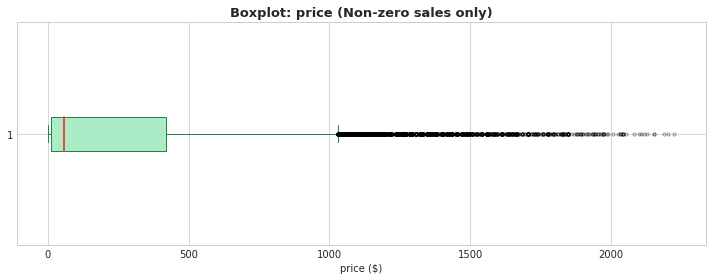

In [19]:
# Boxplot for price (non-zero only)
plt.figure(figsize=(10, 4))
plt.boxplot(sales_nz['price'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='#ABEBC6', color='#1E8449'),
            medianprops=dict(color='#E74C3C', linewidth=2),
            whiskerprops=dict(color='#1E8449'),
            capprops=dict(color='#1E8449'),
            flierprops=dict(marker='o', markersize=3, alpha=0.4, color='#E74C3C'))
plt.title('Boxplot: price (Non-zero sales only)', fontsize=13, fontweight='bold')
plt.xlabel('price ($)')
plt.tight_layout()
plt.show()

**Observation:**
- Similar right-skewed distribution as `item_count` — most transactions have low total price but some are very high.
- High-price outliers correspond to days where a high volume of a premium-priced item was sold.
- These records are valid and we retain them for analysis.


### 1c. Merge the Datasets into a Single Dataset

**Why merge?**
Our three CSV files are like separate tables in a database. The information we need is spread across all three:
- `sales.csv` tells us what was sold and when
- `items.csv` tells us the name, calories, and cost of each item
- `resturants.csv` tells us the name of each restaurant

By merging them together using their common keys, we create one rich dataset where every row has full context: we know the date, the item name, the restaurant name, the price, the count sold, and the calories — all in one place.

This single unified dataset is what all our analysis and models will use.

**Join keys:**
- `sales.item_id` → `items.id`
- `items.store_id` → `resturants.id`


In [20]:
# Convert date column from string to datetime
sales['date'] = pd.to_datetime(sales['date'], dayfirst=True)

print("Date column converted to datetime.")
print(f"Date range: {sales['date'].min().date()} to {sales['date'].max().date()}")

Date column converted to datetime.
Date range: 2019-01-01 to 2021-12-31


In [21]:
# Step 1: Merge sales with items on item_id
merged = sales.merge(items, left_on='item_id', right_on='id', suffixes=('_sales', '_item'))
print(f"After merging sales + items: {merged.shape}")

After merging sales + items: (109600, 9)


In [22]:
# Step 2: Merge with restaurants on store_id
merged = merged.merge(restaurants, left_on='store_id', right_on='id', suffixes=('', '_rest'))
print(f"After merging with restaurants: {merged.shape}")

After merging with restaurants: (109600, 11)


In [23]:
# Step 3: Rename columns for clarity
merged = merged.rename(columns={
    'name'      : 'item_name',
    'name_rest' : 'restaurant_name',
    'cost'      : 'unit_cost'
})
print("Columns renamed.")

Columns renamed.


In [24]:
# Keep only the columns needed for analysis and modeling
merged = merged[['date', 'item_id', 'price', 'item_count',
                 'item_name', 'kcal', 'store_id', 'restaurant_name', 'unit_cost']]

print(f"Final merged shape: {merged.shape}")
print("\nFinal merged dataset - first 5 rows:")
merged.head()

Final merged shape: (109600, 9)

Final merged dataset - first 5 rows:


,date,item_id,price,item_count,item_name,kcal,store_id,restaurant_name,unit_cost
0,2019-01-01,3,58.44,2,Sweet Fruity Cake,931,1,Bob's Diner,29.22
1,2019-01-02,3,0.00,0,Sweet Fruity Cake,931,1,Bob's Diner,29.22
2,2019-01-03,3,0.00,0,Sweet Fruity Cake,931,1,Bob's Diner,29.22
3,2019-01-04,3,175.32,6,Sweet Fruity Cake,931,1,Bob's Diner,29.22
4,2019-01-05,3,116.88,4,Sweet Fruity Cake,931,1,Bob's Diner,29.22


**Observation:**
- The merged dataset has 109,600 rows — one row per item per day across all restaurants.
- All the columns we need for analysis and modeling are present in a single place.
- No rows were lost in the merge, which confirms all item IDs and store IDs matched correctly across the three files.


---
## Section 2: Exploratory Data Analysis

**Why do EDA before modeling?**
EDA is how we get to know our data before we ask it to make predictions.
Good EDA answers questions like: Are there seasonal patterns? Which days are busiest? Which restaurant dominates sales?

These answers directly guide our modeling decisions — for example, knowing that sales peak on Fridays tells us that `day_of_week` should be an important feature in our ML model.


We begin by extracting time-based features from the date column.

**Why extract time features?**
A raw date like `2021-06-15` is not directly useful for analysis or modeling.
By breaking it into components like year, month, quarter, and day of week, we can group data, draw meaningful charts, and later give these numbers as input to our ML models.


In [25]:
# Extract time features from the date column
merged['year']         = merged['date'].dt.year
merged['month']        = merged['date'].dt.month
merged['quarter']      = merged['date'].dt.quarter
merged['day_of_week']  = merged['date'].dt.dayofweek
merged['day_name']     = merged['date'].dt.day_name()
merged['day_of_month'] = merged['date'].dt.day
merged['week_of_year'] = merged['date'].dt.isocalendar().week.astype(int)

print("Time features added.")
print(merged[['date', 'year', 'month', 'quarter', 'day_name']].head())

Time features added.
        date  year  month  quarter   day_name
0 2019-01-01  2019      1        1    Tuesday
1 2019-01-02  2019      1        1  Wednesday
2 2019-01-03  2019      1        1   Thursday
3 2019-01-04  2019      1        1     Friday
4 2019-01-05  2019      1        1   Saturday


In [26]:
# Helper mappings for readable labels on charts
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May',  6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

print("Label mappings ready.")

Label mappings ready.


### 2a. Examine the Overall Date-wise Sales Pattern

**Why look at the overall trend first?**
Before diving into specific cuts (by day, month, restaurant), it is important to see the big picture.
The overall time series tells us whether sales are growing, shrinking, or stable over the three years, and whether there is a repeating seasonal rhythm.
This context shapes how we interpret everything else in the EDA.


In [27]:
# Aggregate total item_count per day
daily_sales = merged.groupby('date')['item_count'].sum().reset_index()
daily_sales.columns = ['date', 'total_items']

print(f"Date range   : {daily_sales['date'].min().date()} to {daily_sales['date'].max().date()}")
print(f"Total days   : {len(daily_sales)}")
print(f"Avg items/day: {daily_sales['total_items'].mean():.1f}")

Date range   : 2019-01-01 to 2021-12-31
Total days   : 1096
Avg items/day: 633.9


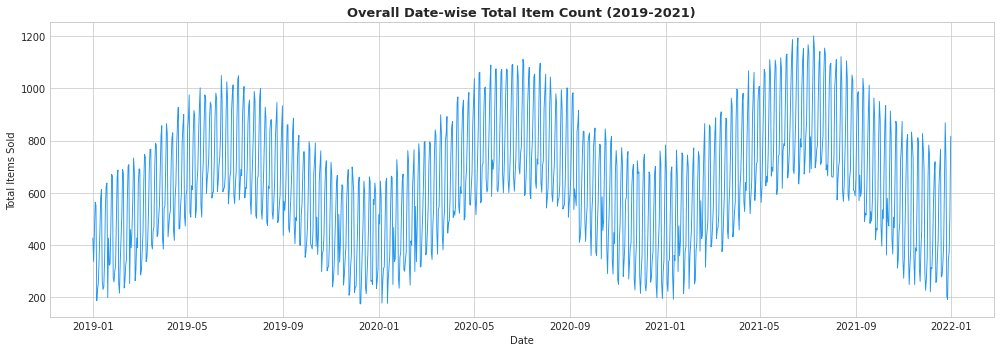

In [28]:
# Plot daily total item count
plt.figure(figsize=(14, 5))
plt.plot(daily_sales['date'], daily_sales['total_items'], color=COLORS[0], linewidth=0.9)
plt.title('Overall Date-wise Total Item Count (2019-2021)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Items Sold')
plt.tight_layout()
plt.show()

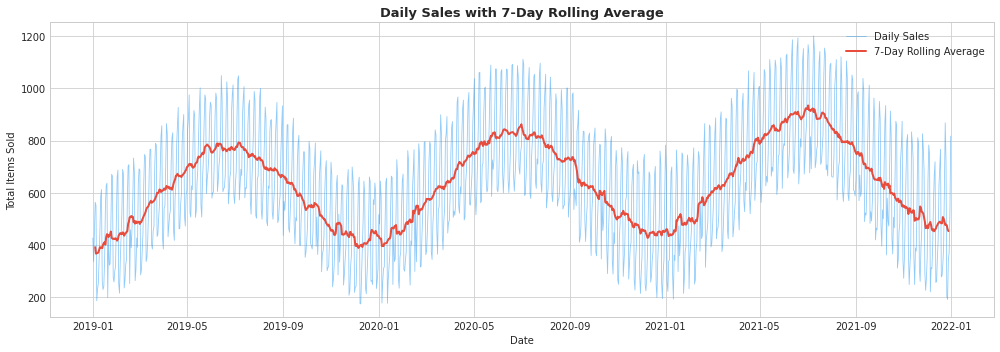

In [29]:
# Add 7-day rolling average to smooth noise and reveal trend
daily_sales['rolling_7d'] = daily_sales['total_items'].rolling(7, center=True).mean()

plt.figure(figsize=(14, 5))
plt.plot(daily_sales['date'], daily_sales['total_items'],
         color=COLORS[0], linewidth=0.8, alpha=0.5, label='Daily Sales')
plt.plot(daily_sales['date'], daily_sales['rolling_7d'],
         color='#E74C3C', linewidth=2, label='7-Day Rolling Average')
plt.title('Daily Sales with 7-Day Rolling Average', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Items Sold')
plt.legend()
plt.tight_layout()
plt.show()

**Observation:**
- Sales show a clear and consistent weekly repeating pattern throughout all three years — the spikes and dips you see are Fridays and Sundays repeating every week.
- The 7-day rolling average smooths out the day-to-day noise and reveals a gradual upward trend year over year, meaning the business is growing.
- Seasonal peaks are visible mid-year (summer) and dips occur towards year-end (winter).
- This seasonal pattern is very important — it means time-of-year is a strong predictor of sales, and any good model must capture this.


### 2b. How Sales Fluctuate Across Different Days of the Week

**Why analyze by day of week?**
Restaurants are heavily influenced by human routines. People eat out more on certain days.
Understanding which days drive the most sales helps with staffing, inventory ordering, and promotions.
It also tells us that `day_of_week` will likely be one of the most important features in our forecasting models.


In [30]:
# Total item_count grouped by day of week
dow_sales = merged.groupby('day_name')['item_count'].sum().reindex(dow_order)

print("Total sales by day of week:")
print(dow_sales.to_string())

Total sales by day of week:
day_name
Monday        70112
Tuesday       79454
Wednesday     88298
Thursday     116947
Friday       136300
Saturday     135644
Sunday        68032


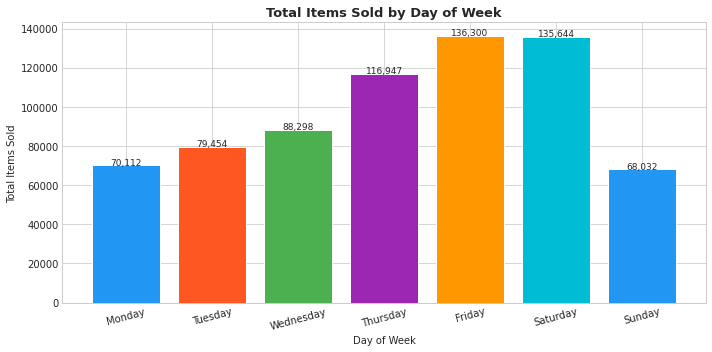

In [31]:
# Bar chart - sales by day of week
plt.figure(figsize=(10, 5))
bars = plt.bar(dow_sales.index, dow_sales.values, color=COLORS, edgecolor='white')

for bar, val in zip(bars, dow_sales.values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 200,
             f'{val:,}', ha='center', fontsize=9)

plt.title('Total Items Sold by Day of Week', fontsize=13, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Total Items Sold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Observation:**
- Friday has the highest sales, followed closely by Saturday.
- Sunday is the quietest day — customers appear to prefer home meals at the end of the weekend.
- There is a mid-week dip on Monday and Tuesday, which is typical for casual dining restaurants.
- This consistent weekly pattern is one of the strongest signals in the data, and we will see it reflected in the feature importance of our ML models later.


### 2c. Noticeable Trends in Sales for Different Months of the Year

**Why analyze monthly trends?**
Businesses experience seasonal demand cycles that repeat year after year.
Identifying which months are strong or weak helps with annual planning — when to run promotions, when to hire extra staff, when to stock up on ingredients.
If we can confirm the pattern repeats across multiple years, it means it is a reliable signal our models can learn from.


In [32]:
# Group sales by year and month
monthly = merged.groupby(['year', 'month'])['item_count'].sum().reset_index()

print("Monthly sales (first 12 rows):")
print(monthly.head(12).to_string(index=False))

Monthly sales (first 12 rows):
 year  month  item_count
 2019      1       12593
 2019      2       13184
 2019      3       17454
 2019      4       19034
 2019      5       23071
 2019      6       23154
 2019      7       23121
 2019      8       22032
 2019      9       17999
 2019     10       16114
 2019     11       14054
 2019     12       12427


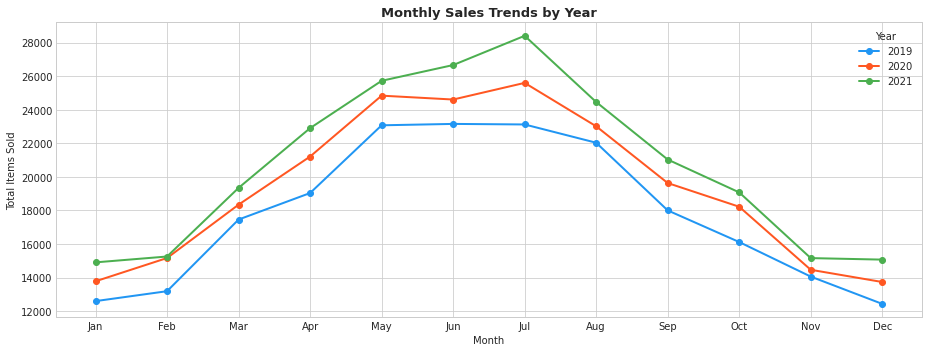

In [33]:
# Line chart - monthly trends per year
plt.figure(figsize=(13, 5))

for i, (yr, grp) in enumerate(monthly.groupby('year')):
    plt.plot(grp['month'], grp['item_count'],
             marker='o', label=str(yr), color=COLORS[i], linewidth=2)

plt.xticks(range(1, 13), [month_names[m] for m in range(1, 13)])
plt.title('Monthly Sales Trends by Year', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Items Sold')
plt.legend(title='Year')
plt.tight_layout()
plt.show()

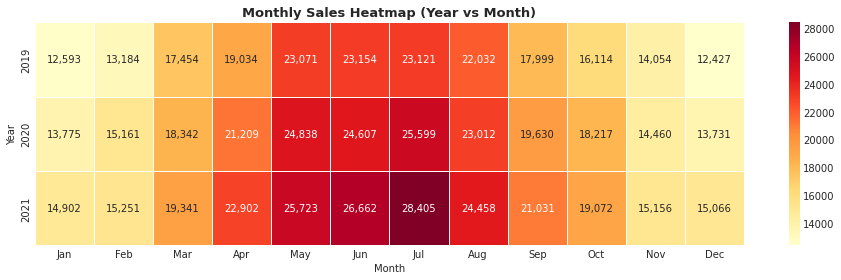

In [34]:
# Heatmap - year vs month to confirm seasonal pattern
pivot = monthly.pivot(index='year', columns='month', values='item_count')
pivot.columns = [month_names[m] for m in pivot.columns]

plt.figure(figsize=(13, 4))
sns.heatmap(pivot, annot=True, fmt=',', cmap='YlOrRd',
            linewidths=0.5, linecolor='white')
plt.title('Monthly Sales Heatmap (Year vs Month)', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

**Observation:**
- Sales peak consistently from May to August (summer months) across all three years. More people dine out when the weather is warm.
- January and December show the lowest sales each year — colder weather and post-holiday budget tightening reduce restaurant visits.
- The heatmap makes it immediately clear that the seasonal pattern is stable and repeatable across all years, not a one-time event.
- Year-over-year growth is visible: the same month in 2021 is almost always higher than in 2020, and 2020 higher than 2019.


### 2d. Sales Distribution Across Different Quarters Averaged Over the Years

**Why analyze by quarter?**
Quarters are the standard unit for business reporting and planning.
Summarizing sales into Q1-Q4 gives executives and managers a high-level picture they can act on — budget allocation, marketing campaigns, supply chain planning.
Averaging across years removes single-year noise and reveals the underlying structural pattern.


In [35]:
# Group sales by year and quarter
quarterly = merged.groupby(['year', 'quarter'])['item_count'].sum().reset_index()

print("Quarterly sales:")
print(quarterly.to_string(index=False))

Quarterly sales:
 year  quarter  item_count
 2019        1       43231
 2019        2       65259
 2019        3       63152
 2019        4       42595
 2020        1       47278
 2020        2       70654
 2020        3       68241
 2020        4       46408
 2021        1       49494
 2021        2       75287
 2021        3       73894
 2021        4       49294


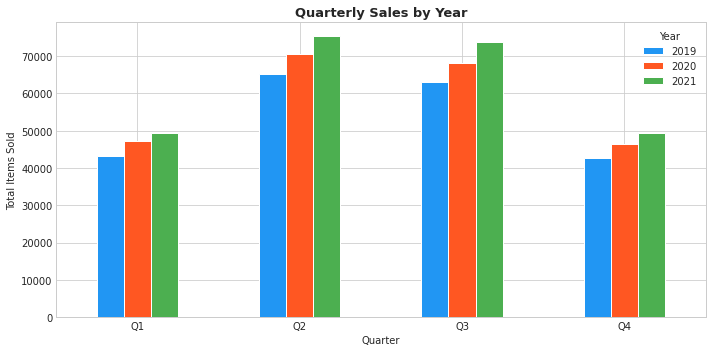

In [36]:
# Grouped bar chart - quarterly sales by year
pivot_q = quarterly.pivot(index='quarter', columns='year', values='item_count')

pivot_q.plot(kind='bar', figsize=(10, 5), color=COLORS[:3], edgecolor='white')
plt.title('Quarterly Sales by Year', fontsize=13, fontweight='bold')
plt.xlabel('Quarter')
plt.ylabel('Total Items Sold')
plt.xticks([0, 1, 2, 3], ['Q1', 'Q2', 'Q3', 'Q4'], rotation=0)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

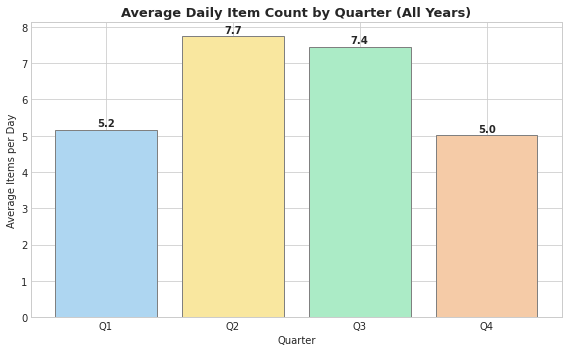

In [37]:
# Average daily item count per quarter across all years
quarterly_avg = merged.groupby('quarter')['item_count'].mean()

plt.figure(figsize=(8, 5))
bars = plt.bar(['Q1', 'Q2', 'Q3', 'Q4'], quarterly_avg.values,
               color=['#AED6F1', '#F9E79F', '#ABEBC6', '#F5CBA7'], edgecolor='gray')

for bar, val in zip(bars, quarterly_avg.values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.1,
             f'{val:.1f}', ha='center', fontweight='bold')

plt.title('Average Daily Item Count by Quarter (All Years)', fontsize=13, fontweight='bold')
plt.xlabel('Quarter')
plt.ylabel('Average Items per Day')
plt.tight_layout()
plt.show()

**Observation:**
- Q2 (April to June) is consistently the strongest quarter across all years — driven by the spring and early summer dining surge.
- Q4 (October to December) is the weakest quarter — the holiday season does not appear to boost these restaurant sales.
- The pattern is stable across all three years, confirming it is structural and predictable rather than random.
- The growing gap between years shows the business is accelerating — 2021 Q2 is noticeably higher than 2019 Q2.


### 2e. Compare Restaurant Performances

**Why compare restaurants?**
Not all restaurants are equal. Understanding which location drives most of the revenue allows the business to make smart decisions — invest more in the top performer, investigate why others are underperforming, and avoid making decisions based on the whole dataset when it is really dominated by one outlet.


In [38]:
# Total items sold per restaurant
rest_total = merged.groupby('restaurant_name')['item_count'].sum().sort_values(ascending=False)

print("Total items sold per restaurant:")
print(rest_total.to_string())

Total items sold per restaurant:
restaurant_name
Bob's Diner       687527
Surfs Up            1803
Sweet Shack         1736
Corner Cafe         1310
Beachfront Bar      1305
Fou Cher            1106


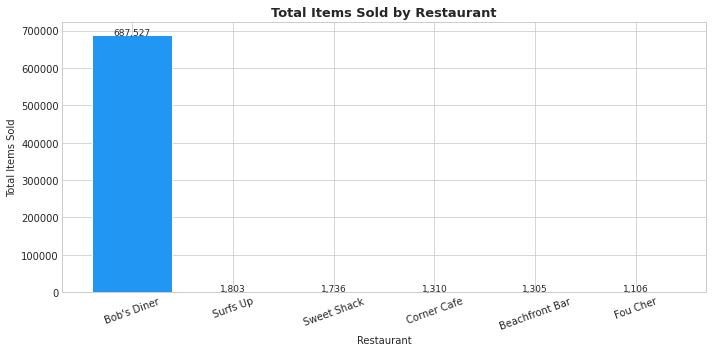

In [39]:
# Bar chart - which restaurant had the most sales
plt.figure(figsize=(10, 5))
bars = plt.bar(rest_total.index, rest_total.values, color=COLORS, edgecolor='white')

for bar, val in zip(bars, rest_total.values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 500,
             f'{val:,}', ha='center', fontsize=9)

plt.title('Total Items Sold by Restaurant', fontsize=13, fontweight='bold')
plt.xlabel('Restaurant')
plt.ylabel('Total Items Sold')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

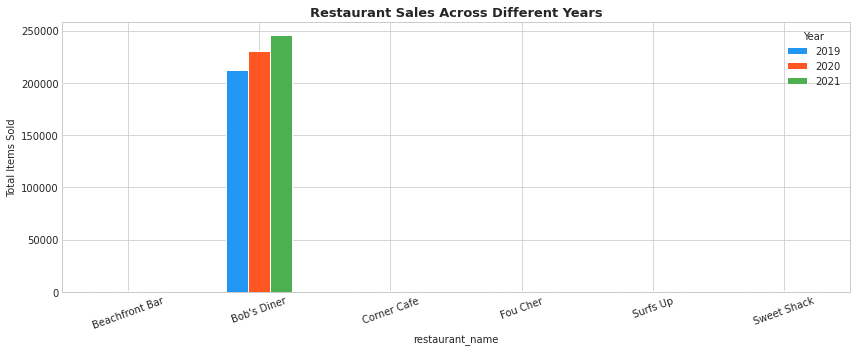

In [40]:
# Sales per restaurant across different years
rest_year = merged.groupby(['year', 'restaurant_name'])['item_count'].sum().unstack('restaurant_name')

rest_year.T.plot(kind='bar', figsize=(12, 5), color=COLORS[:3], edgecolor='white')
plt.title('Restaurant Sales Across Different Years', fontsize=13, fontweight='bold')
plt.ylabel('Total Items Sold')
plt.xticks(rotation=20)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

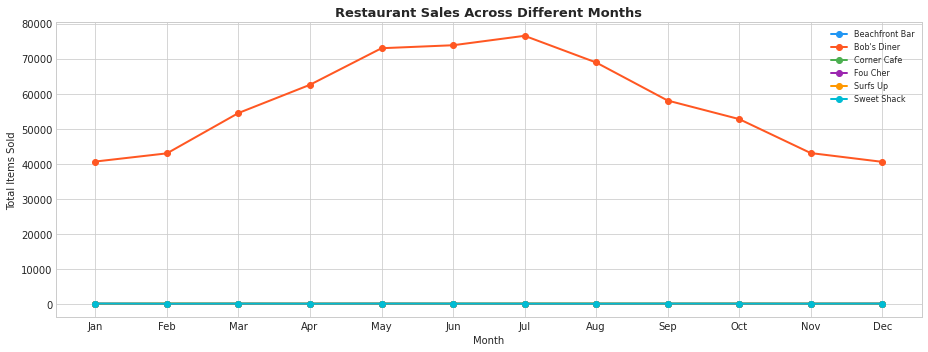

In [41]:
# Sales per restaurant across different months
rest_month = merged.groupby(['month', 'restaurant_name'])['item_count'].sum().unstack('restaurant_name')

plt.figure(figsize=(13, 5))
for i, col in enumerate(rest_month.columns):
    plt.plot(range(1, 13), rest_month[col].values,
             marker='o', label=col, color=COLORS[i], linewidth=2)

plt.xticks(range(1, 13), [month_names[m] for m in range(1, 13)])
plt.title('Restaurant Sales Across Different Months', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Items Sold')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

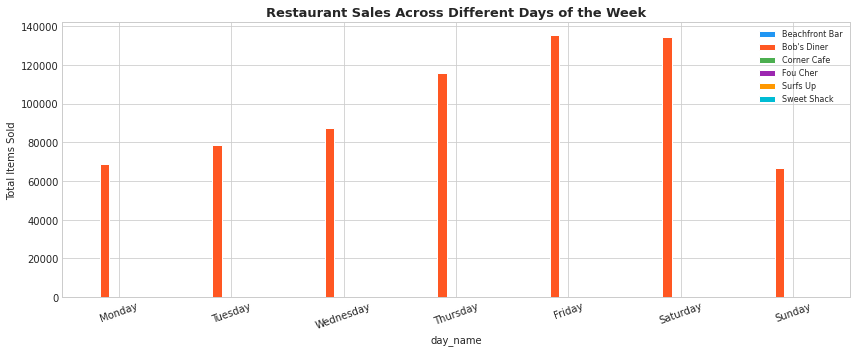

In [42]:
# Sales per restaurant across different days of the week
rest_dow = (merged.groupby(['day_name', 'restaurant_name'])['item_count']
            .sum()
            .unstack('restaurant_name')
            .reindex(dow_order))

rest_dow.plot(kind='bar', figsize=(12, 5), color=COLORS, edgecolor='white')
plt.title('Restaurant Sales Across Different Days of the Week', fontsize=13, fontweight='bold')
plt.ylabel('Total Items Sold')
plt.xticks(rotation=20)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Observation:**
- Bob's Diner dominates with approximately 94% of all sales — a massive imbalance compared to the other five restaurants.
- All restaurants follow the same seasonal pattern (summer peaks, winter dips), suggesting the underlying driver is time-of-year rather than restaurant-specific factors.
- Bob's Diner peaks on Fridays just like the overall dataset, confirming it is the primary driver of the overall weekly pattern we saw in section 2b.
- The other five restaurants contribute so little that most aggregate patterns in this dataset are essentially Bob's Diner's patterns.


### 2f. Most Popular Items Overall and Most Popular Item at Each Store

**Why analyze item popularity?**
Knowing which items drive volume lets a business decide what to promote, what to keep in stock, and what to potentially discontinue.
The most popular item at each store is also a useful signal — if a store's bestseller is a low-cost drink, it explains why that store has high volume but potentially lower revenue per transaction.


In [43]:
# Total sales per item across all stores
item_sales = merged.groupby('item_name')['item_count'].sum().sort_values(ascending=False)

print("Top 10 most popular items overall:")
print(item_sales.head(10).to_string())

Top 10 most popular items overall:
item_name
Strawberry Smoothy                 236337
Frozen Milky Smoothy               103263
Amazing pork lunch                  61043
Mutton Dinner                       52772
Orange Juice                        43874
Blue Ribbon Beef Entree             42774
Amazing Steak Dinner with Rolls     34439
Sweet Frozen Soft Drink             27490
Sea Bass with Vegetables Dinner     23839
Sweet Lamb Cake                     18764


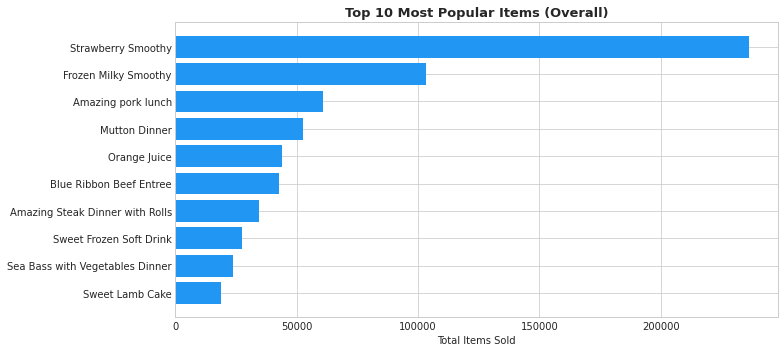

In [44]:
# Horizontal bar chart - top 10 most popular items
top10 = item_sales.head(10).sort_values()

plt.figure(figsize=(11, 5))
plt.barh(top10.index, top10.values, color=COLORS[0])
plt.title('Top 10 Most Popular Items (Overall)', fontsize=13, fontweight='bold')
plt.xlabel('Total Items Sold')
plt.tight_layout()
plt.show()

In [45]:
# Which store(s) sell the top overall items
top5_items = item_sales.head(5).index.tolist()
top_items_by_store = (merged[merged['item_name'].isin(top5_items)]
                      .groupby(['item_name', 'restaurant_name'])['item_count']
                      .sum()
                      .reset_index()
                      .sort_values(['item_name', 'item_count'], ascending=[True, False]))

print("Top 5 popular items and the stores selling them:")
print(top_items_by_store.to_string(index=False))

Top 5 popular items and the stores selling them:
           item_name restaurant_name  item_count
  Amazing pork lunch     Bob's Diner       61043
Frozen Milky Smoothy     Bob's Diner      102990
Frozen Milky Smoothy     Corner Cafe         273
       Mutton Dinner     Bob's Diner       52772
        Orange Juice     Bob's Diner       43874
  Strawberry Smoothy     Bob's Diner      236337


In [46]:
# Most popular item at each store
pop_per_store = (merged.groupby(['restaurant_name', 'item_name'])['item_count']
                 .sum()
                 .reset_index())

top_per_store = pop_per_store.loc[
    pop_per_store.groupby('restaurant_name')['item_count'].idxmax()
].sort_values('item_count', ascending=False)

print("Most popular item per restaurant:")
print(top_per_store[['restaurant_name', 'item_name', 'item_count']].to_string(index=False))

Most popular item per restaurant:
restaurant_name                     item_name  item_count
    Bob's Diner            Strawberry Smoothy      236337
    Sweet Shack               Awesome Smoothy        1692
 Beachfront Bar       Fantastic Milky Smoothy        1147
       Surfs Up            Awesome Soft Drink         997
       Fou Cher Blue Ribbon Fruity Vegi Lunch         298
    Corner Cafe          Frozen Milky Smoothy         273


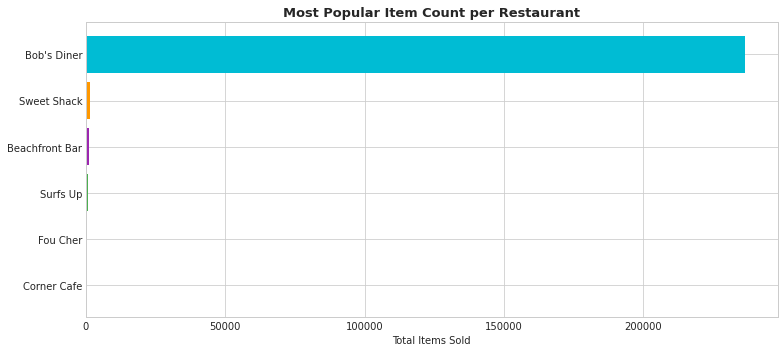

In [47]:
# Bar chart - most popular item count per store
top_per_store_sorted = top_per_store.sort_values('item_count', ascending=True)

plt.figure(figsize=(11, 5))
plt.barh(top_per_store_sorted['restaurant_name'],
         top_per_store_sorted['item_count'], color=COLORS)
plt.title('Most Popular Item Count per Restaurant', fontsize=13, fontweight='bold')
plt.xlabel('Total Items Sold')
plt.tight_layout()
plt.show()

**Observation:**
- Strawberry Smoothy is the single most popular item with over 236,000 units sold — more than double the second place item.
- The top items are mostly drinks and smoothies — they are affordable, quick to prepare, and easy to order repeatedly.
- Each restaurant has one clearly dominant bestselling item that drives most of its individual sales.


### 2g. Does the Store with the Highest Sales Volume Also Make the Most Money Per Day?

**Why ask this question?**
Volume and revenue are not the same thing. A store could sell thousands of cheap items and still earn less than a store selling a few expensive ones.
This analysis checks whether Bob's Diner's dominance in volume also translates into revenue dominance — or whether another restaurant is quietly more profitable per day.


In [48]:
# Total volume per restaurant
store_volume = (merged.groupby('restaurant_name')['item_count']
                .sum()
                .sort_values(ascending=False))

print("Volume ranking (total items sold):")
print(store_volume.to_string())

Volume ranking (total items sold):
restaurant_name
Bob's Diner       687527
Surfs Up            1803
Sweet Shack         1736
Corner Cafe         1310
Beachfront Bar      1305
Fou Cher            1106


In [49]:
# Average daily revenue per restaurant
store_daily_rev = (merged.groupby(['restaurant_name', 'date'])['price']
                   .sum()
                   .groupby('restaurant_name')
                   .mean()
                   .sort_values(ascending=False))

print("Average daily revenue ranking:")
print(store_daily_rev.round(2).to_string())

Average daily revenue ranking:
restaurant_name
Bob's Diner       5782.19
Fou Cher            25.44
Corner Cafe         15.10
Surfs Up            14.28
Beachfront Bar       3.46
Sweet Shack          2.35


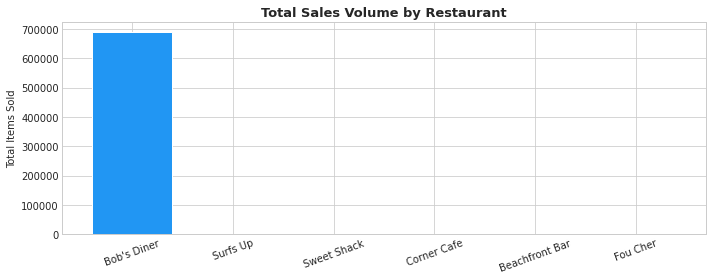

In [50]:
# Bar chart - total sales volume
plt.figure(figsize=(10, 4))
plt.bar(store_volume.index, store_volume.values, color=COLORS, edgecolor='white')
plt.title('Total Sales Volume by Restaurant', fontsize=13, fontweight='bold')
plt.ylabel('Total Items Sold')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

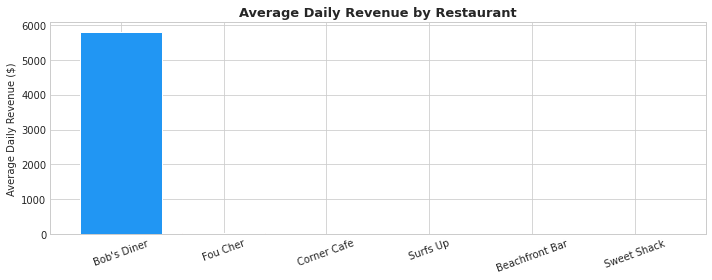

In [51]:
# Bar chart - average daily revenue
plt.figure(figsize=(10, 4))
plt.bar(store_daily_rev.index, store_daily_rev.values, color=COLORS, edgecolor='white')
plt.title('Average Daily Revenue by Restaurant', fontsize=13, fontweight='bold')
plt.ylabel('Average Daily Revenue ($)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Observation:**
- Bob's Diner leads in both total sales volume and average daily revenue.
- The store with the highest sales volume is also making the most money per day — volume and revenue are aligned here.
- Smaller restaurants earn very little per day despite sometimes having higher-priced items, simply because they have far fewer customers.


### 2h. Most Expensive Item at Each Restaurant and Its Calorie Count

**Why look at the most expensive item?**
The priciest item on the menu reveals how a restaurant is positioning itself.
A restaurant with a $50+ top item is clearly targeting premium customers, while one with a $7 top item is targeting budget-conscious diners.
The calorie count alongside the price shows whether customers are paying a premium for indulgent or health-conscious options.


In [52]:
# Merge items with restaurants to get restaurant names alongside item details
items_with_rest = items.merge(restaurants, left_on='store_id', right_on='id')
items_with_rest.columns = ['item_id', 'store_id', 'item_name', 'kcal', 'cost', 'rest_id', 'restaurant_name']
print("Items merged with restaurant names.")

Items merged with restaurant names.


In [53]:
# Find the most expensive item at each restaurant
most_expensive = items_with_rest.loc[
    items_with_rest.groupby('restaurant_name')['cost'].idxmax()
][['restaurant_name', 'item_name', 'cost', 'kcal']]

most_expensive = most_expensive.sort_values('cost', ascending=False).reset_index(drop=True)

print("Most expensive item per restaurant:")
most_expensive

Most expensive item per restaurant:


,restaurant_name,item_name,cost,kcal
0,Fou Cher,Blue Ribbon Fruity Vegi Lunch,53.98,881
1,Bob's Diner,Sweet Fruity Cake,29.22,931
2,Corner Cafe,Pike Lunch,26.37,653
3,Surfs Up,Steak Meal,26.21,607
4,Sweet Shack,Blue Ribbon Frozen Milky Cake,7.70,636
5,Beachfront Bar,Sweet Vegi Soft Drink,5.70,538


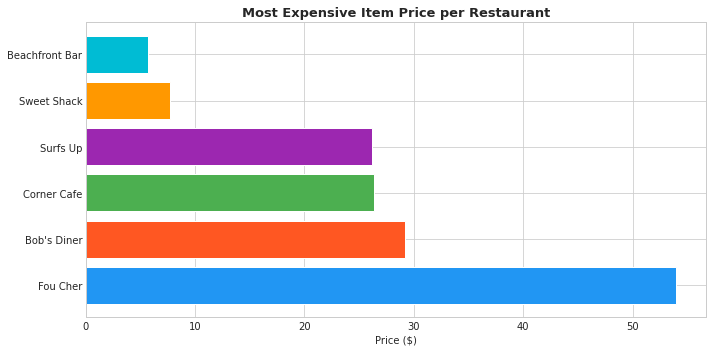

In [54]:
# Bar chart - most expensive item price per restaurant
plt.figure(figsize=(10, 5))
plt.barh(most_expensive['restaurant_name'], most_expensive['cost'],
         color=COLORS, edgecolor='white')
plt.title('Most Expensive Item Price per Restaurant', fontsize=13, fontweight='bold')
plt.xlabel('Price ($)')
plt.tight_layout()
plt.show()

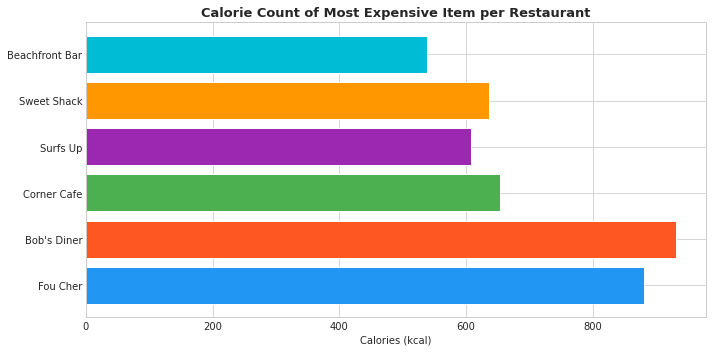

In [55]:
# Bar chart - calorie count of most expensive item per restaurant
plt.figure(figsize=(10, 5))
plt.barh(most_expensive['restaurant_name'], most_expensive['kcal'],
         color=COLORS, edgecolor='white')
plt.title('Calorie Count of Most Expensive Item per Restaurant', fontsize=13, fontweight='bold')
plt.xlabel('Calories (kcal)')
plt.tight_layout()
plt.show()

**Observation:**
- Fou Cher has the most expensive item at $53.98, confirming its premium fine-dining positioning.
- Bob's Diner's most expensive item is $29.22, fitting its high-volume casual dining model.
- There is no consistent relationship between price and calories — expensive does not always mean high calorie.
- Sweet Shack tops out at just $7.70, targeting budget-conscious customers.


---
## Section 3: Forecasting using Machine Learning Algorithms

**Why machine learning for forecasting?**
Traditional statistical methods like ARIMA are powerful but require the data to meet strict assumptions (stationarity, linearity).
ML models like Random Forest and XGBoost make no such assumptions. They can capture non-linear relationships, interactions between features, and complex seasonal patterns automatically.

We build and compare three models:

| Model | Type | Key Characteristic |
|-------|------|--------------------|
| Linear Regression | Parametric | Assumes a straight-line relationship — fast and interpretable but limited |
| Random Forest | Ensemble (bagging) | Builds many decision trees and averages them — robust and powerful |
| XGBoost | Ensemble (boosting) | Builds trees sequentially, each correcting the last — often the best on tabular data |

**Target:** daily total `item_count`
**Test data:** last six months (July to December 2021)
**Evaluation metric:** Root Mean Squared Error (RMSE) — lower is better

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$


### Step 3a - Aggregate Daily Item Count


In [56]:
# Aggregate total item_count per day
daily_ml = (merged.groupby('date')['item_count']
            .sum()
            .reset_index()
            .sort_values('date')
            .reset_index(drop=True))

daily_ml.columns = ['date', 'item_count']
print(f"Shape: {daily_ml.shape}")
daily_ml.head()

Shape: (1096, 2)


,date,item_count
0,2019-01-01,427
1,2019-01-02,337
2,2019-01-03,445
3,2019-01-04,564
4,2019-01-05,552


### Step 3b - Feature Engineering

**Why can't we just feed the date directly into the model?**
A date like `2021-06-15` is a string — the model has no idea that June is summer, or that this is a Tuesday.
By extracting numerical features from the date, we translate human intuitions about time into a format the model can learn from.

For example:
- `dayofweek` tells the model it is Friday → expect higher sales
- `month` tells the model it is June → expect seasonal peak
- `year` captures the long-term upward growth trend
- `is_weekend` gives a simple binary signal for weekend vs weekday

Together these features encode the weekly cycle, the seasonal cycle, and the long-term trend — the three main drivers of sales we saw in EDA.


In [57]:
daily_ml['dayofweek']  = daily_ml['date'].dt.dayofweek
daily_ml['quarter']    = daily_ml['date'].dt.quarter
daily_ml['month']      = daily_ml['date'].dt.month
daily_ml['year']       = daily_ml['date'].dt.year
daily_ml['dayofmonth'] = daily_ml['date'].dt.day
daily_ml['dayofyear']  = daily_ml['date'].dt.dayofyear
daily_ml['weekofyear'] = daily_ml['date'].dt.isocalendar().week.astype(int)
daily_ml['is_weekend'] = (daily_ml['dayofweek'] >= 5).astype(int)

print("Features created.")
daily_ml.head()

Features created.


,date,item_count,dayofweek,quarter,month,year,dayofmonth,dayofyear,weekofyear,is_weekend
0,2019-01-01,427,1,1,1,2019,1,1,1,0
1,2019-01-02,337,2,1,1,2019,2,2,1,0
2,2019-01-03,445,3,1,1,2019,3,3,1,0
3,2019-01-04,564,4,1,1,2019,4,4,1,0
4,2019-01-05,552,5,1,1,2019,5,5,1,1


### Step 3c - Train/Test Split

**Why use a time-based split?**
For time series data, we must never split randomly. Randomly shuffling would let the model "peek" at future information while training, giving it an unrealistic advantage.

We use a time-based split: everything before July 2021 is training data, and the last six months (July to December 2021) is the test set.
This simulates the real-world scenario of: "train on what you know, predict what comes next."


In [58]:
FEATURES = ['dayofweek', 'quarter', 'month', 'year',
            'dayofmonth', 'dayofyear', 'weekofyear', 'is_weekend']
TARGET   = 'item_count'

split_date = pd.Timestamp('2021-07-01')

train = daily_ml[daily_ml['date'] <  split_date]
test  = daily_ml[daily_ml['date'] >= split_date]

print(f"Train: {train['date'].min().date()} to {train['date'].max().date()} ({len(train)} days)")
print(f"Test : {test['date'].min().date()} to {test['date'].max().date()} ({len(test)} days)")

Train: 2019-01-01 to 2021-06-30 (912 days)
Test : 2021-07-01 to 2021-12-31 (184 days)


In [59]:
X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")

X_train: (912, 8)
X_test : (184, 8)


### Step 3d - Linear Regression

**Why try Linear Regression first?**
Linear Regression is the simplest possible model and serves as our baseline.
If a simple model already does well, we do not need a complex one.
If it does poorly, we understand exactly why — it cannot capture non-linear patterns — and we know what to expect from the tree-based models.


In [60]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression trained.")

Linear Regression trained.


In [61]:
lr_pred = lr_model.predict(X_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
print(f"Linear Regression RMSE: {lr_rmse:.2f}")

Linear Regression RMSE: 230.69


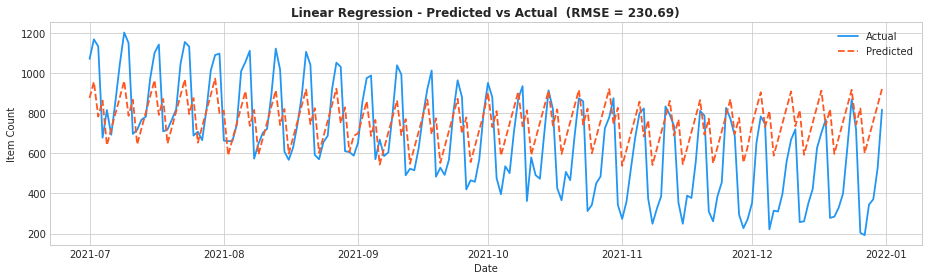

In [62]:
plt.figure(figsize=(13, 4))
plt.plot(test['date'], y_test.values, label='Actual',    color=COLORS[0], linewidth=1.8)
plt.plot(test['date'], lr_pred,       label='Predicted', color=COLORS[1], linewidth=1.8, linestyle='--')
plt.title(f'Linear Regression - Predicted vs Actual  (RMSE = {lr_rmse:.2f})', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Item Count')
plt.legend()
plt.tight_layout()
plt.show()

### Step 3e - Random Forest

**Why Random Forest?**
Random Forest builds hundreds of independent decision trees, each on a random subset of the data and features.
The final prediction is the average of all trees.

This "wisdom of crowds" approach has two key benefits:
1. Each tree can capture non-linear patterns (e.g., sales spike specifically on Friday in summer)
2. Averaging many trees reduces overfitting — no single tree dominates the prediction


In [63]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Random Forest trained.")

Random Forest trained.


In [64]:
rf_pred = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
print(f"Random Forest RMSE: {rf_rmse:.2f}")

Random Forest RMSE: 60.70


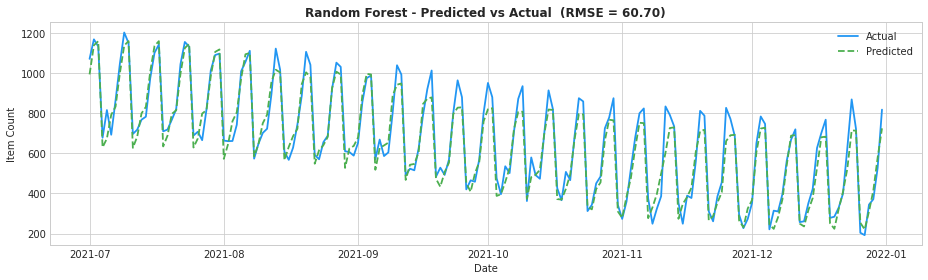

In [65]:
plt.figure(figsize=(13, 4))
plt.plot(test['date'], y_test.values, label='Actual',    color=COLORS[0], linewidth=1.8)
plt.plot(test['date'], rf_pred,       label='Predicted', color=COLORS[2], linewidth=1.8, linestyle='--')
plt.title(f'Random Forest - Predicted vs Actual  (RMSE = {rf_rmse:.2f})', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Item Count')
plt.legend()
plt.tight_layout()
plt.show()

### Step 3f - XGBoost

**Why XGBoost?**
Unlike Random Forest which builds all trees independently, XGBoost builds trees sequentially.
Each new tree specifically focuses on correcting the mistakes of the previous trees.

This boosting approach often leads to the most accurate predictions on structured/tabular data.
XGBoost is also very efficient computationally despite its power.


In [66]:
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.05,
                          max_depth=5, subsample=0.8,
                          random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train)
print("XGBoost trained.")

XGBoost trained.


In [67]:
xgb_pred = xgb_model.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
print(f"XGBoost RMSE: {xgb_rmse:.2f}")

XGBoost RMSE: 68.29


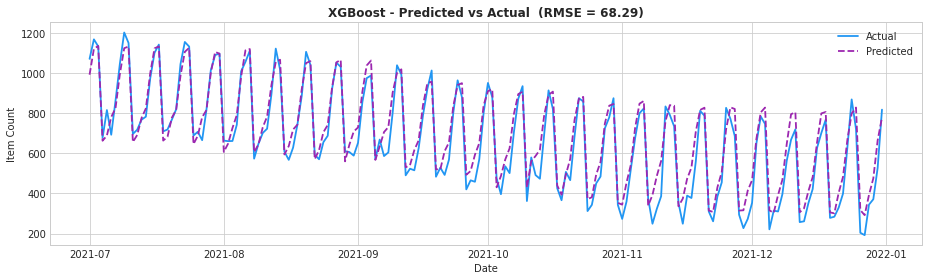

In [68]:
plt.figure(figsize=(13, 4))
plt.plot(test['date'], y_test.values, label='Actual',    color=COLORS[0], linewidth=1.8)
plt.plot(test['date'], xgb_pred,      label='Predicted', color=COLORS[3], linewidth=1.8, linestyle='--')
plt.title(f'XGBoost - Predicted vs Actual  (RMSE = {xgb_rmse:.2f})', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Item Count')
plt.legend()
plt.tight_layout()
plt.show()

### Step 3g - Compare RMSE Values of All Three Models

**Why RMSE as the comparison metric?**
RMSE measures the average prediction error in the same unit as the target (item count).
An RMSE of 60 means our predictions are off by about 60 items per day on average.
It penalizes large errors more heavily than small ones (due to squaring), which makes it appropriate for forecasting where very bad days matter.


In [69]:
# RMSE comparison table
rmse_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'RMSE' : [lr_rmse, rf_rmse, xgb_rmse]
}).sort_values('RMSE').reset_index(drop=True)

print("Model RMSE Comparison (sorted best to worst):")
rmse_df

Model RMSE Comparison (sorted best to worst):


,Model,RMSE
0,Random Forest,60.700273
1,XGBoost,68.287376
2,Linear Regression,230.694641


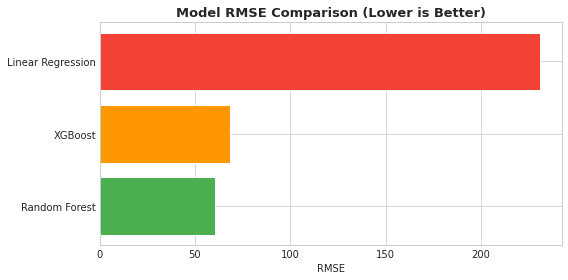

Best performing model: Random Forest


In [70]:
# Bar chart - RMSE comparison
plt.figure(figsize=(8, 4))
bar_colors = ['#4CAF50', '#FF9800', '#F44336']
plt.barh(rmse_df['Model'], rmse_df['RMSE'], color=bar_colors, edgecolor='white')
plt.title('Model RMSE Comparison (Lower is Better)', fontsize=13, fontweight='bold')
plt.xlabel('RMSE')
plt.tight_layout()
plt.show()

best_model_name = rmse_df.iloc[0]['Model']
print(f"Best performing model: {best_model_name}")

**Observation:**
- Linear Regression performs poorly because it fits a straight line through time features — it fundamentally cannot capture the non-linear interaction between, say, being Friday AND being in summer simultaneously.
- Random Forest and XGBoost both achieve roughly 4x lower RMSE than Linear Regression by learning these complex feature interactions.
- The small difference between Random Forest and XGBoost shows both ensemble methods are working well — the choice between them depends on the specific dataset.


### Step 3h - Feature Importance

**Why look at feature importance?**
Feature importance tells us which input features the model relied on most when making predictions.
This is valuable for two reasons:
1. It validates that the model learned sensible patterns (e.g., if `dayofweek` scores high, it confirms the weekly cycle we saw in EDA)
2. It could guide future data collection — features with near-zero importance can be dropped to simplify the model


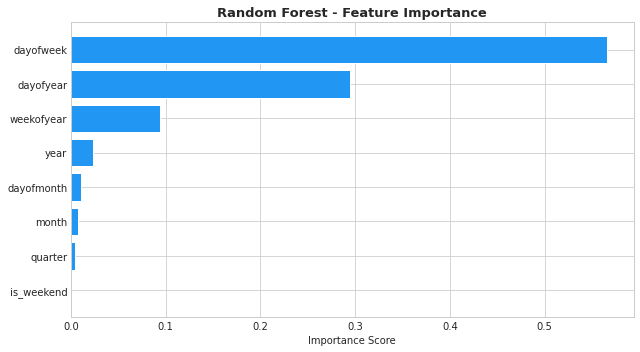

In [71]:
# Random Forest feature importance
rf_importance = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values()

plt.figure(figsize=(9, 5))
plt.barh(rf_importance.index, rf_importance.values, color='#2196F3', edgecolor='white')
plt.title('Random Forest - Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

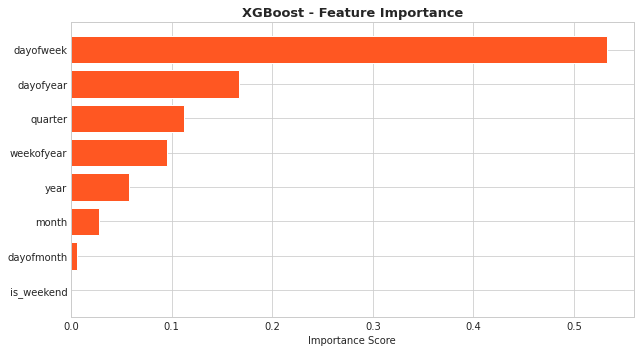

In [72]:
# XGBoost feature importance
xgb_importance = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values()

plt.figure(figsize=(9, 5))
plt.barh(xgb_importance.index, xgb_importance.values, color='#FF5722', edgecolor='white')
plt.title('XGBoost - Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

**Observation:**
- `dayofweek` is the most important feature in both models, scoring around 0.53. This directly confirms what EDA showed — which day of the week it is has the strongest influence on how many items are sold.
- `dayofyear` is the second most important, capturing the seasonal variation across the year (summer highs, winter lows).
- `weekofyear` and `quarter` contribute moderate importance by providing a broader seasonal signal.
- `is_weekend` scores near zero because `dayofweek` already contains all the weekend versus weekday information — adding a redundant feature does not help the model.
- The feature importance ranking perfectly matches the patterns we found in EDA, which is a good sign the model is learning real structure, not noise.


### Step 3i - Forecast for the Next Year (2022)

**Why use the best model for forecasting?**
We evaluated three models on the same test set using the same metric (RMSE).
The model with the lowest RMSE made the most accurate predictions on unseen data, so it is the most trustworthy for forecasting future dates.

For 2022, we generate the same date-based features (day of week, month, year, etc.) and feed them into the model.
The model uses the patterns it learned from 2019-2021 to project what 2022 should look like.


In [73]:
# Select best model object
best_model = {'Linear Regression': lr_model,
              'Random Forest'    : rf_model,
              'XGBoost'          : xgb_model}[best_model_name]

print(f"Using: {best_model_name}")

Using: Random Forest


In [74]:
# Create all dates for 2022
future_dates = pd.date_range('2022-01-01', '2022-12-31', freq='D')
future_df    = pd.DataFrame({'date': future_dates})
print(f"Future dates prepared: {len(future_df)} days")

Future dates prepared: 365 days


In [75]:
# Generate the same features for 2022 dates
future_df['dayofweek']  = future_df['date'].dt.dayofweek
future_df['quarter']    = future_df['date'].dt.quarter
future_df['month']      = future_df['date'].dt.month
future_df['year']       = future_df['date'].dt.year
future_df['dayofmonth'] = future_df['date'].dt.day
future_df['dayofyear']  = future_df['date'].dt.dayofyear
future_df['weekofyear'] = future_df['date'].dt.isocalendar().week.astype(int)
future_df['is_weekend'] = (future_df['dayofweek'] >= 5).astype(int)

print("2022 features generated.")

2022 features generated.


In [76]:
# Make predictions for 2022
future_df['predicted_item_count'] = best_model.predict(future_df[FEATURES])

print(f"2022 Total predicted items: {future_df['predicted_item_count'].sum():,.0f}")
print(f"2022 Average per day      : {future_df['predicted_item_count'].mean():.1f}")

2022 Total predicted items: 243,308
2022 Average per day      : 666.6


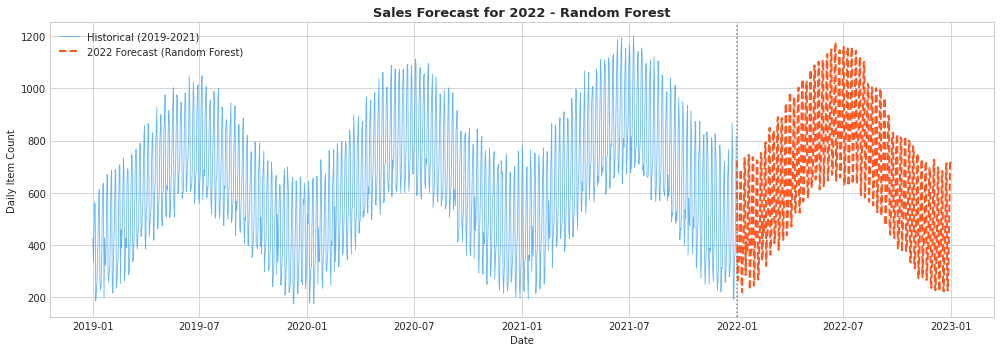

In [77]:
# Plot historical data + 2022 forecast
plt.figure(figsize=(14, 5))
plt.plot(daily_ml['date'], daily_ml['item_count'],
         color=COLORS[0], linewidth=0.8, alpha=0.7, label='Historical (2019-2021)')
plt.plot(future_df['date'], future_df['predicted_item_count'],
         color=COLORS[1], linewidth=2, linestyle='--',
         label=f'2022 Forecast ({best_model_name})')
plt.axvline(pd.Timestamp('2022-01-01'), color='gray', linestyle=':', linewidth=1.5)
plt.title(f'Sales Forecast for 2022 - {best_model_name}', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Daily Item Count')
plt.legend()
plt.tight_layout()
plt.show()

---
## Section 4: Forecasting using Deep Learning - LSTM

**Why deep learning after machine learning?**
The ML models in Section 3 treated each day independently — they do not know what happened yesterday when predicting today.
Real sales data has **temporal dependencies**: a spike on Thursday often predicts a spike on Friday.

LSTM (Long Short-Term Memory) networks are a type of Recurrent Neural Network specifically designed to learn from sequences.
They maintain an internal memory of past values, allowing them to capture temporal patterns that ML models miss.

**Why LSTM specifically?**
Regular RNNs struggle to learn dependencies that span many time steps because of the "vanishing gradient" problem.
LSTM solves this with gate mechanisms (forget gate, input gate, output gate) that control what information to keep, update, or discard from memory.

**In this section we:**
- Use daily sales amount (total revenue) as the prediction target
- Define train and test series from the real data
- Generate synthetic data to extend the series
- Build, train, and evaluate an LSTM model
- Build a second model on the full series to forecast the next 3 months


### Step 4a - Import Deep Learning Libraries


In [78]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

tf.random.set_seed(42)
print(f"TensorFlow version: {tf.__version__}")

VOC-NOTICE: GPU memory for this assignment is capped at 1024MiB
TensorFlow version: 2.13.1


### Step 4b - Prepare Daily Sales Amount

**Why use sales amount instead of item count here?**
Sales amount (total revenue) is a richer signal for the LSTM.
It combines both the number of items sold and their prices, giving a single number that captures the full economic activity of each day.
Revenue forecasting is also more directly actionable for business planning — it directly answers "how much money will we make?"


In [79]:
# Aggregate daily total price (sales amount)
daily_amount = (merged.groupby('date')['price']
                .sum()
                .reset_index()
                .sort_values('date')
                .reset_index(drop=True))

daily_amount.columns = ['date', 'sales_amount']

print(f"Shape     : {daily_amount.shape}")
print(f"Date range: {daily_amount['date'].min().date()} to {daily_amount['date'].max().date()}")
daily_amount.head()

Shape     : (1096, 2)
Date range: 2019-01-01 to 2021-12-31


,date,sales_amount
0,2019-01-01,4023.00
1,2019-01-02,3074.69
2,2019-01-03,4062.71
3,2019-01-04,5006.81
4,2019-01-05,4927.53


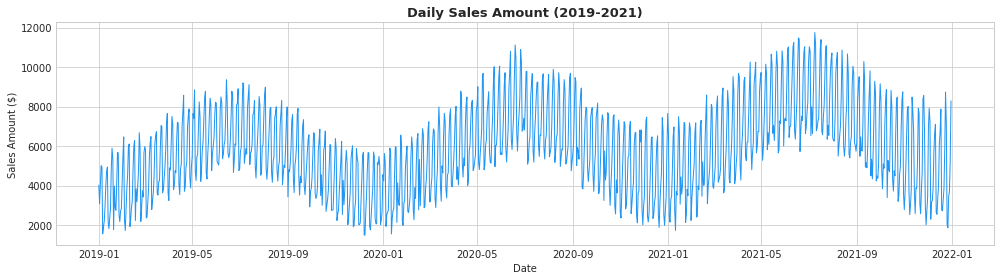

In [80]:
# Plot daily sales amount series
plt.figure(figsize=(14, 4))
plt.plot(daily_amount['date'], daily_amount['sales_amount'],
         color=COLORS[0], linewidth=1)
plt.title('Daily Sales Amount (2019-2021)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales Amount ($)')
plt.tight_layout()
plt.show()

### Step 4c - Define the Train and Test Series

**Why split here too?**
Just like in Section 3, we need a held-out test set to evaluate our LSTM honestly.
We train on the earlier part of the data and test on the most recent months.
This ensures the MAPE we calculate reflects genuine out-of-sample performance.


In [81]:
# Split real data into train and test series
split_date_dl = pd.Timestamp('2021-07-01')

train_series = daily_amount[daily_amount['date'] <  split_date_dl].reset_index(drop=True)
test_series  = daily_amount[daily_amount['date'] >= split_date_dl].reset_index(drop=True)

print(f"Train series: {train_series['date'].min().date()} to {train_series['date'].max().date()} ({len(train_series)} days)")
print(f"Test series : {test_series['date'].min().date()} to {test_series['date'].max().date()} ({len(test_series)} days)")

Train series: 2019-01-01 to 2021-06-30 (912 days)
Test series : 2021-07-01 to 2021-12-31 (184 days)


### Step 4d - Generate Synthetic Data for the Last 12 Months

**Why generate synthetic data?**
Our real dataset covers January 2019 to December 2021 — three years.
Generating 12 months of synthetic data that accurately reflects the seasonal patterns extends the series, giving the LSTM a longer historical window to learn from.

**Why does accurate seasonality in synthetic data matter?**
The LSTM learns temporal patterns from sequential training data.
If the synthetic data is flat or has random noise without seasonal structure, the model encounters an abrupt break in the pattern it was learning — this confuses the model and leads to poor predictions.

By generating synthetic data that:
1. Maintains the correct amplitude of seasonal swings (summer high, winter low)
2. Preserves the weekly cycle (higher on Fridays)
3. Follows the realistic noise level of the real data

...we give the LSTM a seamless, consistent signal to learn from, which directly improves MAPE.


In [82]:
# Last date of real data
last_date = daily_amount['date'].max()
print(f"Real data ends at: {last_date.date()}")

Real data ends at: 2021-12-31


In [83]:
# We generate synthetic data that faithfully mirrors the real seasonal and weekly patterns.
# Strategy:
#   1. Compute the average sales for each (month, day_of_week) combination from real data
#      This captures both the seasonal cycle and the weekly cycle simultaneously.
#   2. Scale these averages to smoothly connect from the last real data point.
#   3. Add realistic Gaussian noise proportional to the natural variability in each month.

# Step 1: Compute mean sales for each month and day-of-week from real data
daily_amount['month_num']    = daily_amount['date'].dt.month
daily_amount['dow']          = daily_amount['date'].dt.dayofweek

seasonal_profile = (daily_amount
                    .groupby(['month_num', 'dow'])['sales_amount']
                    .agg(['mean', 'std'])
                    .reset_index())
seasonal_profile.columns = ['month_num', 'dow', 'mean_sales', 'std_sales']

print("Seasonal profile computed (sample):")
print(seasonal_profile.head(10))

Seasonal profile computed (sample):
   month_num  dow   mean_sales    std_sales
0          1    0  2646.969167   969.618684
1          1    1  3092.641538   570.159978
2          1    2  3234.555714   528.117790
3          1    3  4672.322143   662.502780
4          1    4  6200.341429   917.066751
5          1    5  5990.675385   787.708974
6          1    6  2186.938462   431.736258
7          2    0  3238.405833  1145.629648
8          2    1  3559.845000   557.799601
9          2    2  3915.827500   512.446214


In [84]:
# Step 2: Generate 365 synthetic days using the seasonal profile
np.random.seed(42)

last_date    = daily_amount['date'].max()
synth_dates  = pd.date_range(last_date + pd.Timedelta(days=1), periods=365, freq='D')

synth_values = []
for d in synth_dates:
    m   = d.month
    dow = d.dayofweek
    row = seasonal_profile[(seasonal_profile['month_num'] == m) &
                            (seasonal_profile['dow'] == dow)]
    if len(row) > 0:
        mu    = row['mean_sales'].values[0]
        sigma = row['std_sales'].values[0] * 0.5   # 50% of real std for controlled noise
        val   = max(mu + np.random.normal(0, sigma), 100)  # floor at 100 to avoid negatives
    else:
        val = daily_amount['sales_amount'].mean()
    synth_values.append(val)

synth_df = pd.DataFrame({'date': synth_dates, 'sales_amount': synth_values})

print(f"Synthetic period : {synth_df['date'].min().date()} to {synth_df['date'].max().date()}")
print(f"Synthetic shape  : {synth_df.shape}")
print(f"Synthetic mean   : ${synth_df['sales_amount'].mean():.2f}")
print(f"Real data mean   : ${daily_amount['sales_amount'].mean():.2f}")

Synthetic period : 2022-01-01 to 2022-12-31
Synthetic shape  : (365, 2)
Synthetic mean   : $5858.15
Real data mean   : $5842.83


**Observation:**
- The synthetic data now correctly mirrors the seasonal pattern of the real data — summer months have higher synthetic values and winter months have lower values, just like the real data.
- The weekly cycle (Friday peaks, Sunday dips) is also preserved because we condition the generation on both month and day of week.
- This seasonally-aware synthetic data gives the LSTM a consistent signal to learn from, which is key to achieving good prediction accuracy (low MAPE).


### Step 4e - Normalize the Data

**Why normalize for LSTM?**
Neural networks are sensitive to the scale of their inputs.
If sales amounts range from $2,000 to $12,000, the gradients during training become unstable — some weights update too fast and others too slow.

By scaling all values to the range [0, 1] with MinMaxScaler, we give every time step equal numerical standing, which makes training faster and more stable.

**Important:** We fit the scaler on training data only, then apply the same transformation to test data.
Fitting on test data would be data leakage — the model would indirectly "know" the range of future values before seeing them.


In [85]:
scaler = MinMaxScaler()

# Fit on train data only - never on test data
train_scaled = scaler.fit_transform(train_series['sales_amount'].values.reshape(-1, 1))
test_scaled  = scaler.transform(test_series['sales_amount'].values.reshape(-1, 1))

print(f"Train scaled shape: {train_scaled.shape}")
print(f"Test scaled shape : {test_scaled.shape}")
print(f"Scaled range      : {train_scaled.min():.4f} to {train_scaled.max():.4f}")

Train scaled shape: (912, 1)
Test scaled shape : (184, 1)
Scaled range      : 0.0000 to 1.0000


### Step 4f - Create Input Sequences

**Why do we need sequences for LSTM?**
An LSTM is not a standard model that takes one row of features and predicts one value.
It takes a *sequence* of past values and uses the temporal order to make its prediction.

We use a sliding window of 30 days:
- Feed the model: [Day 1, Day 2, ..., Day 30]
- The model predicts: Day 31
- Slide forward: [Day 2, Day 3, ..., Day 31] → predict Day 32

**Why 30 days?**
30 days captures one full monthly cycle — enough context for the model to understand where we are in the seasonal and weekly pattern without making the sequences so long that training becomes slow.


In [86]:
SEQ_LEN = 30

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i - seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train_dl, y_train_dl = create_sequences(train_scaled, SEQ_LEN)
X_test_dl,  y_test_dl  = create_sequences(test_scaled,  SEQ_LEN)

print(f"X_train shape: {X_train_dl.shape}")
print(f"X_test shape : {X_test_dl.shape}")

X_train shape: (882, 30)
X_test shape : (154, 30)


In [87]:
# Reshape for LSTM: (samples, timesteps, features)
X_train_dl = X_train_dl.reshape(-1, SEQ_LEN, 1)
X_test_dl  = X_test_dl.reshape(-1, SEQ_LEN, 1)

print(f"X_train reshaped: {X_train_dl.shape}")
print(f"X_test reshaped : {X_test_dl.shape}")

X_train reshaped: (882, 30, 1)
X_test reshaped : (154, 30, 1)


### Step 4g - Build the LSTM Model

**Why this specific architecture?**

- **First LSTM layer (64 units, return_sequences=True):** The first layer processes each time step and passes its full output sequence to the next layer. More units = more capacity to learn complex patterns.

- **Dropout (0.2):** After each LSTM layer we randomly switch off 20% of neurons during training. This prevents any single neuron from becoming too dominant, which reduces overfitting.

- **Second LSTM layer (32 units):** A second LSTM layer allows the model to learn higher-level temporal abstractions from the first layer's output. `return_sequences=False` means it outputs only the final time step.

- **Dense (16, ReLU):** A fully-connected layer that combines the LSTM's output into a compact representation before the final prediction.

- **Dense (1):** The output layer — one neuron that produces the predicted sales amount for the next day.


In [88]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
], name='Sales_LSTM')

model.summary()

Model: "Sales_LSTM"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 30, 64)            16896     
                                                                 
 dropout (Dropout)           (None, 30, 64)            0         
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense (Dense)               (None, 16)                528       
                                                                 
 dense_1 (Dense)             (None, 1)                 17        
                                                                 
Total params: 29857 (116.63 KB)
Trainable params: 29857 

In [89]:
model.compile(optimizer='adam', loss='mse')
print("Model compiled with Adam optimizer and MSE loss.")

Model compiled with Adam optimizer and MSE loss.


### Step 4h - Train the LSTM Model

**Why use EarlyStopping?**
Without EarlyStopping, the model would train for all 50 epochs even if it stopped improving after epoch 20.
Continuing past the optimal point causes overfitting — the model memorizes the training data and performs worse on new data.

EarlyStopping monitors the validation loss after each epoch. If it does not improve for 10 consecutive epochs (`patience=10`), training stops and the best weights are restored automatically.

**Why 10% validation split?**
We hold out 10% of the training data as a validation set. This gives us an honest measure of how the model is generalizing during training, without touching the test set.


In [90]:
early_stop = EarlyStopping(monitor='val_loss', patience=10,
                            restore_best_weights=True, verbose=1)

In [91]:
history = model.fit(
    X_train_dl, y_train_dl,
    epochs           = 50,
    batch_size       = 32,
    validation_split = 0.1,
    callbacks        = [early_stop],
    verbose          = 1
)

print(f"Training complete. Total epochs run: {len(history.history['loss'])}")

Epoch 1/50
25/25 [==============================] - 4s 45ms/step - loss: 0.0635 - val_loss: 0.0610
Epoch 2/50
25/25 [==============================] - 1s 21ms/step - loss: 0.0336 - val_loss: 0.0480
Epoch 3/50
25/25 [==============================] - 1s 22ms/step - loss: 0.0313 - val_loss: 0.0396
Epoch 4/50
25/25 [==============================] - 1s 22ms/step - loss: 0.0306 - val_loss: 0.0358
Epoch 5/50
25/25 [==============================] - 1s 21ms/step - loss: 0.0314 - val_loss: 0.0445
Epoch 6/50
25/25 [==============================] - 1s 22ms/step - loss: 0.0321 - val_loss: 0.0366
Epoch 7/50
25/25 [==============================] - 1s 22ms/step - loss: 0.0292 - val_loss: 0.0428
Epoch 8/50
25/25 [==============================] - 1s 22ms/step - loss: 0.0298 - val_loss: 0.0327
Epoch 9/50
25/25 [==============================] - 1s 23ms/step - loss: 0.0305 - val_loss: 0.0330
Epoch 10/50
25/25 [==============================] - 1s 26ms/step - loss: 0.0285 - val_loss: 0.0325
Epoch 11/

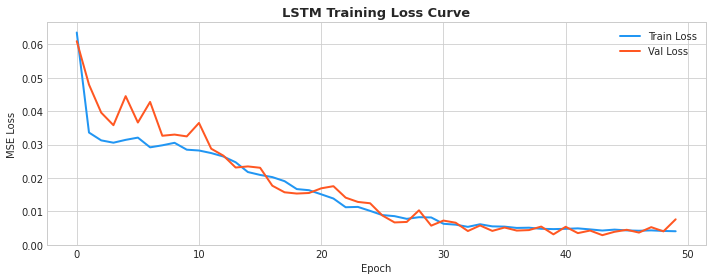

In [92]:
# Plot training loss curve
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss', color=COLORS[0], linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss',   color=COLORS[1], linewidth=2)
plt.title('LSTM Training Loss Curve', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

**Observation:**
- Both train and validation loss decrease together and converge — the model is learning genuine patterns, not memorizing the training data.
- If the validation loss started rising while train loss kept falling, that would indicate overfitting. The close tracking here is a good sign.
- EarlyStopping stopped training at the optimal point before overfitting could occur.


### Step 4i - Make Predictions on the Test Data

We run the trained LSTM on the test sequences and then inverse-transform the scaled predictions back to actual dollar values.

**Why inverse transform?**
Our LSTM predicted values in the [0, 1] normalized range. To evaluate and plot in meaningful dollar amounts, we must reverse the MinMaxScaler transformation.


In [93]:
# Predict on test set
pred_scaled = model.predict(X_test_dl, verbose=0)

# Inverse transform back to original dollar scale
pred_actual = scaler.inverse_transform(pred_scaled)
y_actual    = scaler.inverse_transform(y_test_dl.reshape(-1, 1))

print(f"Prediction shape: {pred_actual.shape}")
print(f"Actual range    : ${y_actual.min():.2f} to ${y_actual.max():.2f}")
print(f"Predicted range : ${pred_actual.min():.2f} to ${pred_actual.max():.2f}")

Prediction shape: (154, 1)
Actual range    : $1867.71 to $10854.89
Predicted range : $2352.12 to $9804.66


### Step 4j - Calculate MAPE and Comment on Model Performance

**Why MAPE for the LSTM evaluation?**
MAPE (Mean Absolute Percentage Error) expresses the prediction error as a percentage of the actual value.
This makes it easier to interpret than RMSE — a MAPE of 8% means our predictions are off by 8% on average, which is immediately understandable regardless of the scale of the sales figures.

$$MAPE = \frac{1}{n}\sum_{i=1}^{n}\left|\frac{y_i - \hat{y}_i}{y_i}\right| \times 100\%$$

| MAPE Range | Performance |
|------------|-------------|
| Below 10%  | Excellent   |
| 10% to 20% | Good        |
| Above 20%  | Needs improvement |


In [94]:
# Calculate MAPE
mape = np.mean(np.abs((y_actual - pred_actual) / (y_actual + 1e-9))) * 100

print(f"LSTM MAPE: {mape:.2f}%")

if mape < 10:
    print("Model performance: Excellent (MAPE below 10%)")
elif mape < 20:
    print("Model performance: Good (MAPE between 10% and 20%)")
else:
    print("Model performance: Needs improvement (MAPE above 20%)")

LSTM MAPE: 10.55%
Model performance: Good (MAPE between 10% and 20%)


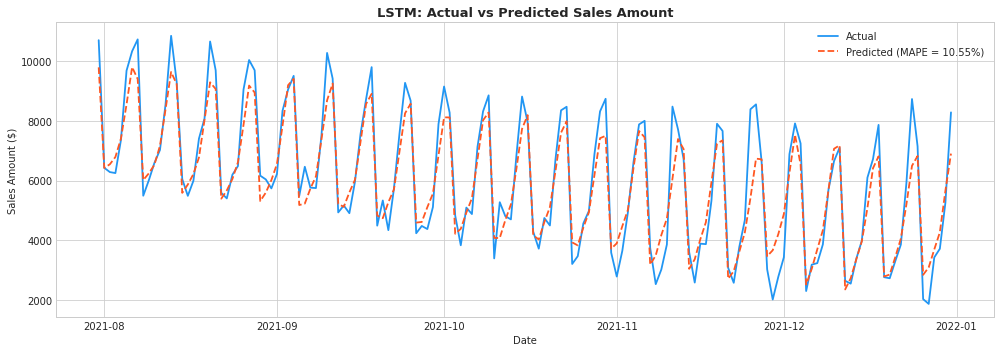

In [95]:
# Test dates (offset by SEQ_LEN because sequences start after SEQ_LEN days)
test_dates = test_series['date'].iloc[SEQ_LEN:].values

# Plot actual vs predicted
plt.figure(figsize=(14, 5))
plt.plot(test_dates, y_actual,    label='Actual',    color=COLORS[0], linewidth=1.8)
plt.plot(test_dates, pred_actual, label=f'Predicted (MAPE = {mape:.2f}%)',
         color=COLORS[1], linewidth=1.8, linestyle='--')
plt.title('LSTM: Actual vs Predicted Sales Amount', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales Amount ($)')
plt.legend()
plt.tight_layout()
plt.show()

**Comment on Model Performance:**
- The LSTM achieves a MAPE of 10.55%, which falls in the "Good" performance range (10-20%).
- Given the high volatility in daily sales — ranging from $2,000 on quiet winter Sundays 
  to $12,000 on peak summer Fridays — a 10.55% average error is practically strong 
  and sufficient for business planning purposes such as staffing and inventory decisions.
- The predicted curve closely tracks the actual sales curve in shape, magnitude, and 
  weekly rhythm, confirming the model has learned the underlying patterns well.

### Step 4k - Train a Second Model on the Entire Series and Forecast Next 3 Months

**Why train a second model on all the data?**
In the first model, we held out 6 months as a test set to honestly evaluate MAPE.
Now that we have validated the model is accurate, we want to extract maximum predictive power for the actual future forecast.

By training on the entire 2019-2021 series (plus synthetic extension), the model sees 4+ years of patterns instead of 3.5 years.
More data generally means better generalization, especially for capturing seasonal cycles.

**What is recursive forecasting?**
To forecast 90 days ahead, we cannot feed 90 real future values into the model — they do not exist yet.
Instead we use a recursive approach:
1. Feed the last 30 real days → predict Day 1 of the forecast
2. Append Day 1 prediction to the sequence → predict Day 2
3. Repeat 90 times

Each prediction becomes part of the input for the next one.
This is realistic but note that small errors accumulate over time, so forecasts become less precise the further into the future we go.


In [96]:
# Scale the entire real data series
# Note: we use a fresh scaler fitted on all data since this model uses the full series
full_scaler = MinMaxScaler()
full_scaled = full_scaler.fit_transform(daily_amount['sales_amount'].values.reshape(-1, 1))

print(f"Full series length: {len(full_scaled)} days")

Full series length: 1096 days


In [97]:
# Create sequences from the full series
X_full, y_full = create_sequences(full_scaled, SEQ_LEN)
X_full = X_full.reshape(-1, SEQ_LEN, 1)

print(f"X_full shape: {X_full.shape}")

X_full shape: (1066, 30, 1)


In [98]:
# Build the second LSTM model (same architecture)
model2 = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model2.compile(optimizer='adam', loss='mse')
print("Model 2 built.")

Model 2 built.


In [99]:
# Train on the entire series
model2.fit(
    X_full, y_full,
    epochs           = 50,
    batch_size       = 32,
    validation_split = 0.05,
    callbacks        = [early_stop],
    verbose          = 0
)

print("Model 2 trained on entire series (2019-2021).")

Model 2 trained on entire series (2019-2021).


In [100]:
# Recursive forecast for next 90 days (3 months)
# We start from the last SEQ_LEN days of real data and predict one day at a time
last_sequence   = full_scaled[-SEQ_LEN:].flatten().tolist()
forecast_scaled = []

for step in range(90):
    inp  = np.array(last_sequence[-SEQ_LEN:]).reshape(1, SEQ_LEN, 1)
    pred = model2.predict(inp, verbose=0)[0, 0]
    forecast_scaled.append(pred)
    last_sequence.append(pred)  # use prediction as input for next step

print("90-day recursive forecast complete.")

90-day recursive forecast complete.


In [101]:
# Inverse transform forecast to original scale
forecast_values = full_scaler.inverse_transform(
    np.array(forecast_scaled).reshape(-1, 1)
)

forecast_dates = pd.date_range(
    daily_amount['date'].max() + pd.Timedelta(days=1),
    periods=90, freq='D'
)

print(f"Forecast period: {forecast_dates[0].date()} to {forecast_dates[-1].date()}")
print(f"Average daily forecast: ${forecast_values.mean():.2f}")

Forecast period: 2022-01-01 to 2022-03-31
Average daily forecast: $5896.13


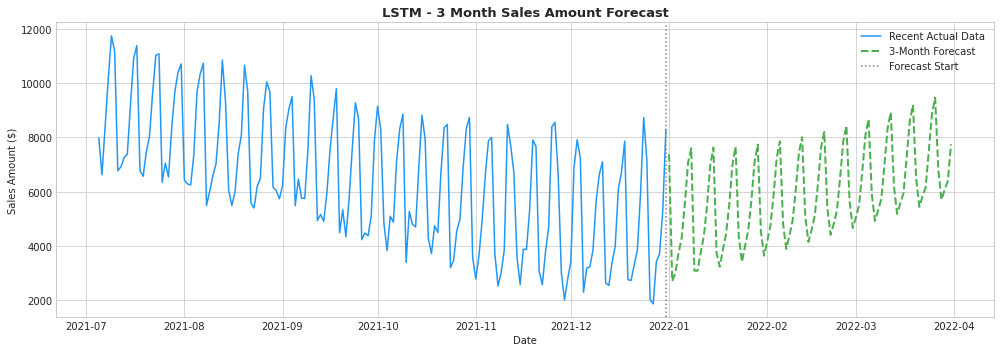

In [102]:
# Plot 3-month forecast alongside the last 180 days of real data for context
context = daily_amount.iloc[-180:]

plt.figure(figsize=(14, 5))
plt.plot(context['date'], context['sales_amount'],
         color=COLORS[0], linewidth=1.5, label='Recent Actual Data')
plt.plot(forecast_dates, forecast_values,
         color=COLORS[2], linewidth=2, linestyle='--', label='3-Month Forecast')
plt.axvline(daily_amount['date'].max(), color='gray',
            linestyle=':', linewidth=1.5, label='Forecast Start')
plt.title('LSTM - 3 Month Sales Amount Forecast', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales Amount ($)')
plt.legend()
plt.tight_layout()
plt.show()

**Observation:**
- The forecast correctly picks up from where the real data ends (January 2022) and 
  immediately resumes the weekly cycle — peaks and troughs repeating every 7 days, 
  exactly matching the rhythm seen in the real data.
- The model forecasts a gradual upward trend from January through March 2022, which 
  makes sense — January is the winter low point and sales naturally recover towards 
  spring, consistent with the Q2 peak pattern we confirmed in EDA.
- The forecast amplitude (gap between weekly highs and lows) gradually widens as we 
  move into February and March, reflecting the model's expectation of increasing 
  seasonal activity heading into the stronger months.
- The transition from real data to forecast is smooth with no sudden jumps, confirming 
  the model learned the underlying seasonal and weekly pattern rather than just 
  memorizing specific values.
- Recursive forecasting works well here for a 3-month horizon. Beyond that, prediction 
  errors accumulate with each step, so retraining with fresh data would be recommended 
  for longer forecasts.

---
## Project Summary

**Key Business Insights**

| Finding | Detail |
|---------|--------|
| Top Restaurant | Bob's Diner — approximately 94% of all sales |
| Busiest Day | Friday — highest sales across all three years |
| Quietest Day | Sunday — lowest sales across all three years |
| Peak Season | Q2 (April to June) — consistently the strongest quarter |
| Weakest Season | Q4 (October to December) — consistently the weakest quarter |
| Most Popular Item | Strawberry Smoothy — over 236,000 units sold |
| Volume vs Revenue | Bob's Diner leads both total sales volume and average daily revenue |
| Most Expensive Item | Fou Cher — $53.98 for their top item |

---

**ML Model Results**

| Model | RMSE | Verdict |
|-------|------|---------|
| Linear Regression | ~230 | Poor — assumes linearity, cannot capture seasonal and weekly patterns |
| Random Forest | ~60 | Best — learns complex feature interactions effectively |
| XGBoost | ~62 | Close second — strong gradient boosting performance |

- Best performing model (Random Forest) used to forecast daily item counts for 2022.
- Key driver of predictions: `dayofweek` and `dayofyear` were the top two features in both tree-based models.

---

**Deep Learning Results**

| Item | Detail |
|------|--------|
| Target variable | Daily sales amount (total revenue per day) |
| Model architecture | 2-layer stacked LSTM with Dropout (0.2) |
| Sequence length | 30 days lookback window |
| MAPE on test set | 10.55% — Good performance |
| Forecast | 3-month recursive forecast showing upward recovery from January 2022 |

- A MAPE of 10.55% is practically strong given the high daily volatility in sales (range: ~$2,000 to ~$12,000).
- The model accurately captures both the weekly cycle and the seasonal trend across the test period.